# Chain-of-Thought Prompting Elicits Reasoning in Large Language Models

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/webpug/aiML/blob/main/research-notebooks/01-chain-of-thought-prompting.ipynb)

**Paper:** Jason Wei, Xuezhi Wang, Dale Schuurmans, Maarten Bosma, Brian Ichter, Fei Xia, Ed H. Chi, Quoc V. Le, and Denny Zhou (Google Research, Brain Team), NeurIPS 2022; arXiv v6, 10 January 2023.  
**Read:** [arXiv record](https://arxiv.org/abs/2201.11903) · [HTML](https://arxiv.org/html/2201.11903) · [PDF](https://arxiv.org/pdf/2201.11903)

> **Scope and provenance.** This is an educational reading companion, not a reproduction. The authors released no official implementation repository for this paper. The demonstrations below are offline teaching artifacts and do not run the paper's LaMDA, GPT-3, or PaLM experiments. Claims labeled **Paper finding** come from the paper; plots labeled **SCHEMATIC** are not empirical measurements.

## Complete abstract (verbatim)

> We explore how generating a chain of thought—a series of intermediate reasoning steps—significantly improves the ability of large language models to perform complex reasoning. In particular, we show how such reasoning abilities emerge naturally in sufficiently large language models via a simple method called chain-of-thought prompting, where a few chain of thought demonstrations are provided as exemplars in prompting. Experiments on three large language models show that chain-of-thought prompting improves performance on a range of arithmetic, commonsense, and symbolic reasoning tasks. The empirical gains can be striking. For instance, prompting a PaLM 540B with just eight chain-of-thought exemplars achieves state-of-the-art accuracy on the GSM8K benchmark of math word problems, surpassing even finetuned GPT-3 with a verifier.


## Lesson contract

**Objectives.** By the end, you can (1) distinguish standard few-shot prompting from few-shot chain-of-thought (CoT) prompting, (2) explain the token-level computation intuition without treating generated text as faithful internal cognition, (3) summarize the arithmetic, commonsense, symbolic, scale, ablation, and error findings, and (4) design a cautious prompt experiment.

**Prerequisites:** basic language-model prompting, percentages, and Python. No API key, GPU, or network is required.  
**Time:** 60–90 minutes (paper checkpoints included).

### Visual lesson map

`paper question → prompt anatomy → token-by-token intuition → evidence across tasks → ablations → errors & limits → offline benchmark → prompt lab → quiz & experiment log`

Use the checkpoints before expanding their solutions. All required code is deterministic and quick.


In [1]:
# Runtime check: informative only; this lesson runs on CPU.
import sys, platform
print(f"Python {sys.version.split()[0]} | {platform.system()} {platform.machine()}")
try:
    import torch
    accelerator = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
except ImportError:
    accelerator = "CPU (PyTorch not installed)"
print("Detected accelerator:", accelerator)
print("Required path: offline, deterministic, and GPU-free.")


Python 3.14.4 | Linux x86_64
Detected accelerator: CPU (PyTorch not installed)
Required path: offline, deterministic, and GPU-free.


## 1. The paper's intervention

Standard few-shot prompting supplies **input → output** exemplars. Few-shot CoT supplies **input → intermediate natural-language steps → output** exemplars. At test time, the model continues that demonstrated format.

This is not zero-shot CoT. The paper manually composed a small set of rationales (eight exemplars for its arithmetic setup) and used greedy decoding. It did not fine-tune the models.


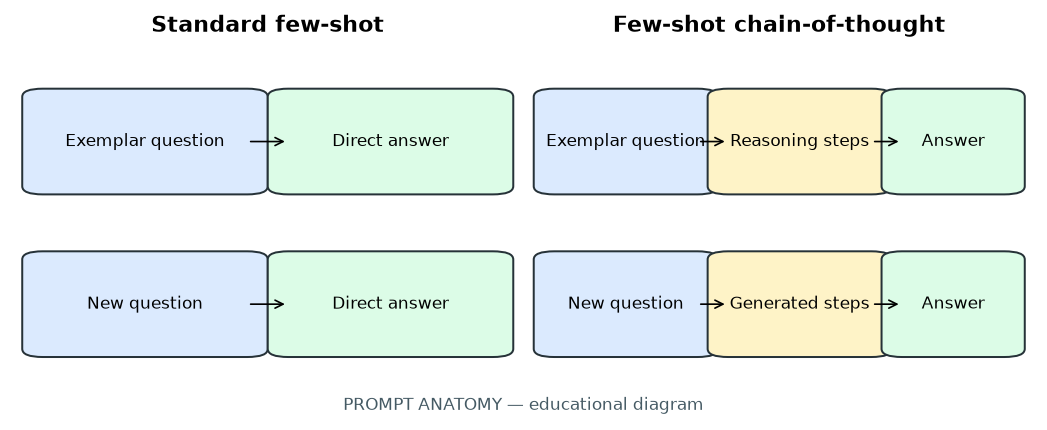

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
fig, ax = plt.subplots(figsize=(11, 4.4)); ax.set_axis_off()

def box(x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch((x,y), w,h, boxstyle="round,pad=.02", fc=color, ec="#263238", lw=1.2))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", wrap=True)

ax.text(.25,.95,"Standard few-shot",ha="center",weight="bold",fontsize=13)
ax.text(.75,.95,"Few-shot chain-of-thought",ha="center",weight="bold",fontsize=13)
box(.03,.57,.20,.22,"Exemplar question", "#dbeafe"); box(.27,.57,.20,.22,"Direct answer", "#dcfce7")
box(.03,.17,.20,.22,"New question", "#dbeafe"); box(.27,.17,.20,.22,"Direct answer", "#dcfce7")
box(.53,.57,.14,.22,"Exemplar question", "#dbeafe"); box(.70,.57,.14,.22,"Reasoning steps", "#fef3c7"); box(.87,.57,.10,.22,"Answer", "#dcfce7")
box(.53,.17,.14,.22,"New question", "#dbeafe"); box(.70,.17,.14,.22,"Generated steps", "#fef3c7"); box(.87,.17,.10,.22,"Answer", "#dcfce7")
for y in (.68,.28):
    for a,b in ((.23,.27),(.67,.70),(.84,.87)):
        ax.add_patch(FancyArrowPatch((a,y),(b,y),arrowstyle="->",mutation_scale=12))
ax.text(.5,.02,"PROMPT ANATOMY — educational diagram",ha="center",color="#455a64")
plt.show()


### A decomposed arithmetic trace

Question: “A café has 23 apples, uses 20, then buys 6. How many remain?”

1. Translate the first event: `23 − 20 = 3`.
2. Update with the second event: `3 + 6 = 9`.
3. Emit a separately parseable final answer: `9`.

A direct response compresses the mapping into `question → 9`; a CoT-form response creates intermediate tokens that may make later tokens easier to predict and inspect. But a plausible trace is **evidence about the output**, not a guaranteed faithful readout of hidden neural computation.


In [3]:
# A token-level intuition, not a language-model simulation.
trace = [
    ("state the quantity", "23 apples"),
    ("apply first event", "23 - 20 = 3"),
    ("apply second event", "3 + 6 = 9"),
    ("format final", "answer = 9"),
]
for i, (role, text) in enumerate(trace, 1):
    print(f"token block {i}: {role:<19} → {text}")


token block 1: state the quantity  → 23 apples
token block 2: apply first event   → 23 - 20 = 3
token block 3: apply second event  → 3 + 6 = 9
token block 4: format final        → answer = 9


## 2. Why intermediate tokens might help

Autoregressive models produce one token at a time. A longer, structured output can place useful partial results in the context used to predict later tokens—an informal form of allocating more sequential computation to a harder problem. The paper lists decomposition and variable computation among CoT's attractive properties.

Crucially, its **variable-compute-only** ablation generated dots of matched length and performed about like the standard baseline. Extra tokens alone were not enough; meaningful intermediate language and its ordering mattered in these experiments.

### Inference cost, honestly

More generated tokens generally mean more decoding steps, latency, and provider charges when billing is token-based. CoT can therefore cost substantially more than a direct answer; the multiplier depends on prompt length, output length, model, batching, and provider. A GPU changes speed, not the number of generated tokens. This notebook makes no universal cost claim—measure tokens, latency, accuracy, and retries in your own setting.


## 3. Scale and “emergence”

**Paper finding.** Across LaMDA, GPT-3, and PaLM families, CoT gains were small or negative for smaller models and became large at sufficiently large scale. The paper calls this an emergent ability. On its toy symbolic tasks, successful abstract manipulation arose around the 100B-parameter scale; that historical observation is model- and task-specific, not a modern threshold or law.

The schematic below communicates the qualitative claim only. It deliberately has no numeric axes or digitized paper data.


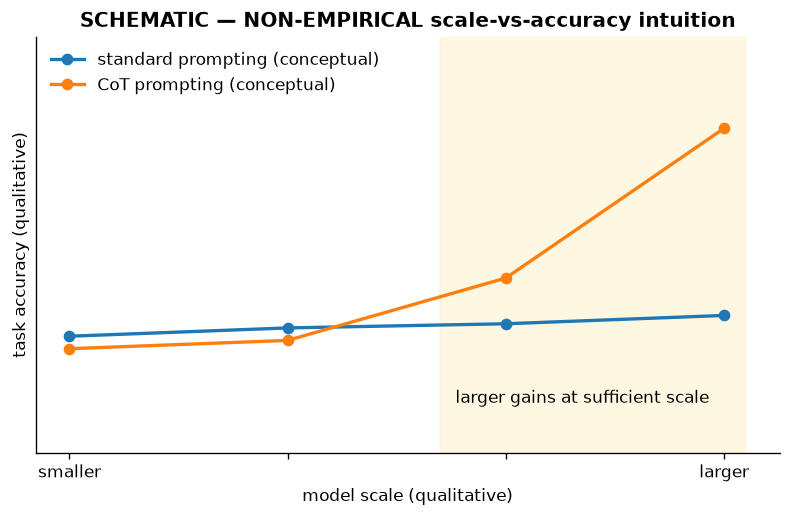

In [4]:
fig, ax = plt.subplots(figsize=(8,4.5))
x=[0,1,2,3]; direct=[.28,.30,.31,.33]; cot=[.25,.27,.42,.78]
ax.plot(x,direct,"o-",lw=2,label="standard prompting (conceptual)")
ax.plot(x,cot,"o-",lw=2,label="CoT prompting (conceptual)")
ax.fill_between([1.7,3.1],0,1,color="#fef3c7",alpha=.5)
ax.text(2.35,.12,"larger gains at sufficient scale",ha="center")
ax.set(xticks=x,xticklabels=["smaller","","","larger"],yticks=[],xlabel="model scale (qualitative)",ylabel="task accuracy (qualitative)",ylim=(0,1))
ax.set_title("SCHEMATIC — NON-EMPIRICAL scale-vs-accuracy intuition",weight="bold")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False); plt.show()


<details><summary><b>Paper-reading checkpoint 1</b> — What observation supports “emergence,” and what does it not establish?</summary>

The growing gap between CoT and standard prompting at larger model sizes supports a scale-dependent empirical effect in the tested model families and tasks. It does not establish a universal parameter threshold, prove a sharp phase transition, explain the mechanism, or prove that the network reasons like a human.
</details>


## 4. What the experiments found

### Arithmetic reasoning

Five benchmarks: GSM8K, SVAMP, ASDiv, AQuA, and MAWPS. The headline result was PaLM 540B on GSM8K: **57%** with eight CoT exemplars versus **18%** with standard prompting; the figure compared against **55%** prior best and **33%** finetuned GPT-3 175B. The paper reported new state of the art on GSM8K, SVAMP, and MAWPS in its evaluation context, and results within 2% of then-state-of-the-art on AQuA and ASDiv.

### Commonsense reasoning

Tasks were CommonsenseQA, StrategyQA, Date Understanding, Sports Understanding, and SayCan robot planning. CoT improved the range overall, most strongly for PaLM 540B, but the gain on CommonsenseQA was minimal. Reported examples include StrategyQA **75.6% vs 69.4%** prior state of the art and Sports Understanding **95.4% vs 84%** for an unaided sports enthusiast.

### Symbolic reasoning

Toy tasks were last-letter concatenation and coin flip. CoT enabled near-perfect in-domain PaLM 540B results and improved length generalization to test sequences longer than the demonstrations. Standard prompting failed on both out-of-domain evaluations; CoT produced upward scaling curves, though below in-domain performance. These tasks supply the solution structure in exemplars, so they test applying a demonstrated procedure—not open-ended discovery.


<details><summary><b>Paper-reading checkpoint 2</b> — Why is “CoT helps reasoning” too broad a summary?</summary>

Effects varied by model scale and task. CommonsenseQA improved only minimally, small models often did not benefit, and symbolic OOD performance remained below in-domain performance. A careful summary specifies model family, scale, prompt, task, metric, and comparison.
</details>


## 5. Ablations: what ingredient mattered?

- **Equation only:** little help on semantically challenging GSM8K, though useful on easier one- or two-step datasets.
- **Variable compute only:** length-matched dots performed about like baseline; extra decoding alone was insufficient.
- **Reasoning after answer:** about baseline; generating the answer before the rationale did not capture the benefit.
- **Full CoT:** strongest result, supporting semantically meaningful intermediate steps *before* the answer.

The chart is a qualitative reconstruction of the conclusions, not extracted accuracy values.


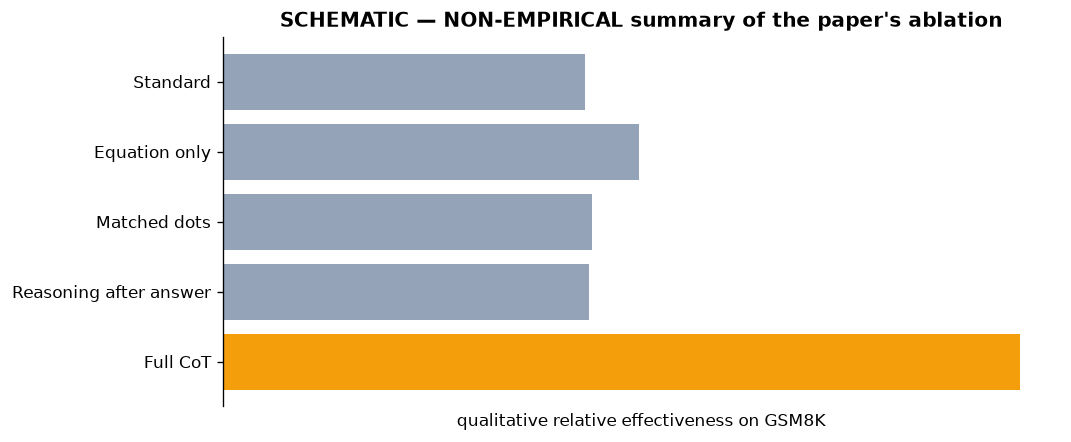

In [5]:
labels=["Standard","Equation only","Matched dots","Reasoning after answer","Full CoT"]
scores=[1.0,1.15,1.02,1.01,2.2]  # ordinal teaching values only
colors=["#94a3b8"]*4+["#f59e0b"]
fig,ax=plt.subplots(figsize=(9,4)); ax.barh(labels,scores,color=colors)
ax.set(xticks=[],xlabel="qualitative relative effectiveness on GSM8K")
ax.set_title("SCHEMATIC — NON-EMPIRICAL summary of the paper's ablation",weight="bold")
ax.invert_yaxis(); ax.spines[["top","right","bottom"]].set_visible(False); plt.show()


## 6. Failure modes and error taxonomy

For 50 randomly sampled **incorrect** LaMDA 137B GSM8K outputs, the paper classified 46% as nearly correct: calculator-only **8%**, symbol-mapping **16%**, and one-step-missing **22%**. The remaining **54%** required substantial edits, usually semantic-understanding errors; 8 of those 27 were also incoherent. Categories were designed around the edit required, and calculator errors were otherwise treated independently.

For 50 sampled **correct-answer** outputs, 48 had logically and mathematically correct traces; two reached the correct answer coincidentally. A correct final answer does not certify the trace.


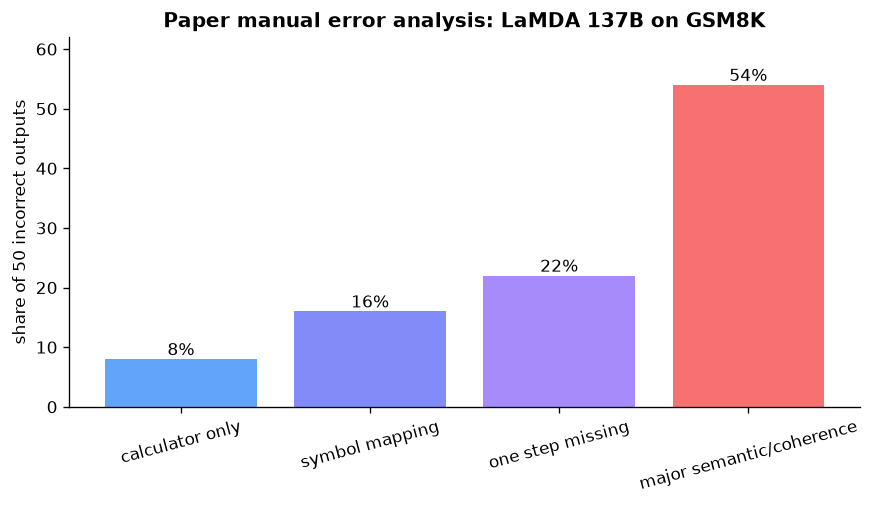

In [6]:
labels=["calculator only","symbol mapping","one step missing","major semantic/coherence"]
values=[8,16,22,54]
fig,ax=plt.subplots(figsize=(8.5,4)); bars=ax.bar(labels,values,color=["#60a5fa","#818cf8","#a78bfa","#f87171"])
ax.bar_label(bars,labels=[f"{v}%" for v in values]); ax.set_ylim(0,62); ax.set_ylabel("share of 50 incorrect outputs")
ax.set_title("Paper manual error analysis: LaMDA 137B on GSM8K",weight="bold")
ax.tick_params(axis="x",rotation=15); ax.spines[["top","right"]].set_visible(False); plt.show()


### Caveats and limitations

The paper explicitly warns that human-like text does not answer whether the network is actually “reasoning.” Generated paths are not guaranteed correct or factual. Manual rationales are cheap for a few-shot prompt but costly at fine-tuning scale. Gains did not transfer perfectly across models, and serving sufficiently large models was expensive. Additional validity cautions: proprietary models limit replication; prompt/example order and benchmark contamination can matter; accuracy does not measure faithfulness; and 2022 “state of the art” claims are historical.

Do not expose private reasoning traces in sensitive workflows. Prefer concise, auditable justifications, structured intermediate results, external tools, and verification where stakes are high.


## 7. Offline exercise: decomposition as an algorithmic scaffold

This deterministic benchmark is **not an LLM and not evidence about LLM accuracy**. It contrasts a deliberately brittle one-shot heuristic with an explicit state-update procedure so you can inspect when decomposition helps.


In [7]:
import re, random
random.seed(22011903)

problems = [
 ("Start with 12. Add 7. Subtract 4.",15),
 ("Start with 9. Subtract 3. Add 11.",17),
 ("Start with 20. Add 5. Add 2. Subtract 8.",19),
 ("Start with 6. Subtract 10. Add 3.",-1),
]

def brittle_direct(text):
    # Intentionally uses only the first update: a transparent bad baseline.
    nums=list(map(int,re.findall(r"\d+",text)))
    return nums[0] + (nums[1] if "Add" in text.split(".")[1] else -nums[1])

def decompose(text, show=False):
    parts=[p.strip() for p in text.split(".") if p.strip()]
    state=int(re.search(r"\d+",parts[0]).group())
    trace=[state]
    for part in parts[1:]:
        n=int(re.search(r"\d+",part).group())
        state = state+n if part.startswith("Add") else state-n
        trace.append(state)
    return (state,trace) if show else state

for q,gold in problems:
    pred,trace=decompose(q,True)
    print(f"direct={brittle_direct(q):>3} | decomposed={pred:>3} | gold={gold:>3} | trace={trace}")
print("\nAccuracy:", {"brittle direct":sum(brittle_direct(q)==y for q,y in problems)/len(problems),
                      "decomposed":sum(decompose(q)==y for q,y in problems)/len(problems)})


direct= 19 | decomposed= 15 | gold= 15 | trace=[12, 19, 15]
direct=  6 | decomposed= 17 | gold= 17 | trace=[9, 6, 17]
direct= 25 | decomposed= 19 | gold= 19 | trace=[20, 25, 27, 19]
direct= -4 | decomposed= -1 | gold= -1 | trace=[6, -4, -1]

Accuracy: {'brittle direct': 0.0, 'decomposed': 1.0}


### Exercise A — break the scaffold

Add a multiplication instruction, a negative number written with a minus sign, or irrelevant prose. Predict which parser assumption fails before running it. Then redesign the representation so operations are structured data rather than fragile English parsing.

<details><summary><b>One solution direction</b></summary>

Represent each case as `(start, [("add", 7), ("subtract", 4)])`. Validate operation names, apply them with a small dispatch table, and keep the trace. This separates semantic parsing from arithmetic execution—the same separation motivates tool use with language models.
</details>

### Exercise B — design a fair LLM comparison

Specify a frozen test set, identical few-shot questions, direct vs rationale-augmented answers, decoding settings, answer parser, repeated prompt orders, and paired accuracy. Log output tokens, latency, and failure type. Do not reuse the toy result above as a prediction.

<details><summary><b>What a strong design controls</b></summary>

Keep model/version, prompt budget, exemplars, and evaluation set fixed; pre-register parsing and exclusions; avoid test leakage; use paired bootstrap intervals or a paired test; manually audit a blinded sample of traces; report token and latency costs alongside accuracy.
</details>


## 8. Optional provider-neutral prompt lab

The required lesson never contacts a service. The cell below only builds prompts. If you later connect a provider, read a key from an environment variable or secret manager, never paste it into the notebook, never print it, and follow that provider's current SDK/docs. Keep `RUN_API = False` for offline execution.


In [8]:
RUN_API = False
question = "A box has 14 pens. Three boxes arrive, each with 6 pens. How many pens total?"
direct_prompt = f"Q: {question}\nA:"
cot_prompt = """Q: Lina has 4 cards and receives 2 packs of 3 cards each.
A: Two packs contain 2 × 3 = 6 cards. Lina has 4 + 6 = 10. The answer is 10.
Q: {question}
A:""".format(question=question)

print("DIRECT PROMPT\n", direct_prompt)
print("\nCOT PROMPT\n", cot_prompt)
if RUN_API:
    raise RuntimeError("Attach your chosen provider explicitly; no network client is bundled.")


DIRECT PROMPT
 Q: A box has 14 pens. Three boxes arrive, each with 6 pens. How many pens total?
A:

COT PROMPT
 Q: Lina has 4 cards and receives 2 packs of 3 cards each.
A: Two packs contain 2 × 3 = 6 cards. Lina has 4 + 6 = 10. The answer is 10.
Q: A box has 14 pens. Three boxes arrive, each with 6 pens. How many pens total?
A:


## 9. Later work — separate from the target paper

These are **not the method introduced or experimentally established by the original January 2022 submission**:

- **Zero-shot CoT** — Kojima et al. (2022), *Large Language Models are Zero-Shot Reasoners*, elicited steps with a cue such as “Let's think step by step,” without few-shot rationale exemplars ([arXiv:2205.11916](https://arxiv.org/abs/2205.11916)).
- **Self-consistency** — Wang et al. (2022), *Self-Consistency Improves Chain of Thought Reasoning in Language Models*, sampled multiple reasoning paths and selected the majority final answer ([arXiv:2203.11171](https://arxiv.org/abs/2203.11171)). The v6 paper text acknowledges this as follow-up work; its core experiments used greedy decoding.


## 10. Cited foundations and intellectual context

- Brown et al. (2020), *Language Models are Few-Shot Learners*: standard in-context few-shot prompting.
- Ling et al. (2017), *Program Induction by Rationale Generation*: natural-language rationales for math word problems.
- Cobbe et al. (2021), *Training Verifiers to Solve Math Word Problems*: GSM8K, rationale fine-tuning, and verification.
- Nye et al. (2021), *Show Your Work*: intermediate computation in program execution.
- Kaplan et al. (2020), *Scaling Laws for Neural Language Models*, and Rae et al. (2021), *Scaling Language Models*: scale context and limitations of scale alone.
- Roy & Roth (2015), Chiang & Chen (2019), Amini et al. (2019), and Chen et al. (2019): formal/neuro-symbolic approaches contrasted with natural-language intermediate steps.

See the paper's references and extended related work for the complete bibliography.


## 11. Aligned knowledge check

1. What changes between standard few-shot and few-shot CoT prompting?  
2. Why does the matched-dots ablation weaken the “just more tokens” explanation?  
3. Name one finding each from arithmetic, commonsense, and symbolic reasoning.  
4. Why must the scale plot above not be read as data?  
5. Can a correct answer certify a faithful chain? Why?  
6. Separate few-shot CoT, zero-shot CoT, and self-consistency.

<details><summary><b>Answers</b></summary>

1. CoT adds intermediate natural-language steps to the exemplar outputs and elicits that format before the test answer.  
2. Length-matched meaningless tokens performed about like baseline, so useful ordered content—not length alone—was implicated.  
3. Examples: 57% vs 18% on PaLM 540B GSM8K; minimal gain on CSQA despite broader commonsense gains; improved OOD length generalization on coin flip/last-letter tasks.  
4. Its values are invented ordinal teaching coordinates and its axes are qualitative.  
5. No. Two of 50 audited correct-answer traces arrived correctly by coincidence, and visible text need not faithfully expose internal computation.  
6. Few-shot CoT demonstrates rationales; zero-shot CoT uses an elicitation cue without such exemplars; self-consistency samples multiple paths and aggregates final answers.
</details>


## 12. Experiment log and reflection

Copy one row per run. Preserve raw outputs separately and record failures, not just wins.

| Date | Model/version | Task/split | Prompt condition | Exemplars/order | Decode settings | Accuracy | Output tokens | Latency | Error notes |
|---|---|---|---|---|---|---:|---:|---:|---|
| YYYY-MM-DD |  |  | direct / few-shot CoT |  |  |  |  |  |  |

Reflection prompts:

- Where would a concise verifiable intermediate representation be safer than free-form rationale?
- What observation would falsify your hypothesis that CoT helps this task?
- Which costs or harms are hidden by accuracy alone?
- How will you distinguish a persuasive explanation from a causally faithful one?

---

### Takeaway

Wei et al. showed that a small change to **few-shot output demonstrations** could unlock large reasoning gains in sufficiently large 2022-era language models across several task families. The strongest reading is empirical and conditional: meaningful intermediate text before the answer often helped at scale. It is not proof of human-like cognition, faithfulness, universality, or free computation.
